In [58]:
import pandas as pd

In [59]:
data_path_res= "res/T1089-P0/T1089_P0_nsfh20_spde_loadings.csv"

In [60]:
data  = pd.read_csv(data_path_res)

In [61]:
data

,Unnamed: 0,1,2,3,4,5,6,7,8,9,10
0,COL1A1,0.000000,0.030321,0.000000,0.000000,0.096990,0.000000,0.000000,0.000000,0.000000,0.872689
1,COL1A2,0.015461,0.040185,0.012165,0.000000,0.122199,0.007136,0.021243,0.017287,0.000000,0.764324
2,IGF2,0.000000,0.028642,0.000000,0.000000,0.147606,0.000000,0.000000,0.000000,0.000000,0.823752
3,COL18A1,0.009298,0.030791,0.000000,0.000000,0.107344,0.000000,0.000000,0.016505,0.000000,0.836062
4,PTGDS,0.031114,0.012545,0.056313,0.000000,0.165488,0.020484,0.020056,0.016700,0.147354,0.529946
...,...,...,...,...,...,...,...,...,...,...,...
1995,TDRP,0.149357,0.110138,0.165894,0.187781,0.081331,0.088502,0.031300,0.106843,0.024864,0.053992
1996,MRPS16,0.192799,0.059821,0.175200,0.111577,0.106530,0.132079,0.089492,0.075086,0.046526,0.010890
1997,PHTF1,0.223404,0.082860,0.123410,0.081763,0.047540,0.129766,0.102319,0.107271,0.073982,0.027684
1998,LOC100406069,0.190221,0.059241,0.048006,0.090275,0.163388,0.070555,0.101085,0.165370,0.087670,0.024188


In [62]:
import pandas as pd

def get_top_genes_per_factor(
    data: pd.DataFrame,
    top_n: int = 10,
    gene_col: str = None,
    factor_cols: list = None,
    sort_by_abs: bool = False
) -> pd.DataFrame:
    """
    Для каждого фактора выбирает top_n генов по весу.

    Параметры
    ----------
    data : pd.DataFrame
        Таблица, где одна колонка содержит названия генов,
        остальные колонки - веса по факторам.
    top_n : int
        Сколько генов брать для каждого фактора.
    gene_col : str
        Название колонки с генами. Если None, берется первая колонка.
    factor_cols : list
        Список колонок факторов. Если None, берутся все кроме gene_col.
    sort_by_abs : bool
        Если True, сортировка идет по abs(weight), иначе по weight.

    Возвращает
    ----------
    pd.DataFrame
        Таблица с колонками:
        ['factor', 'rank', 'gene', 'weight']
    """
    df = data.copy()

    if gene_col is None:
        gene_col = df.columns[0]

    if factor_cols is None:
        factor_cols = [c for c in df.columns if c != gene_col]

    results = []

    for factor in factor_cols:
        tmp = df[[gene_col, factor]].copy()
        tmp.columns = ["gene", "weight"]

        if sort_by_abs:
            tmp = tmp.reindex(tmp["weight"].abs().sort_values(ascending=False).index)
        else:
            tmp = tmp.sort_values("weight", ascending=False)

        tmp = tmp.head(top_n).reset_index(drop=True)
        tmp["factor"] = factor
        tmp["rank"] = range(1, len(tmp) + 1)

        results.append(tmp[["factor", "rank", "gene", "weight"]])

    out = pd.concat(results, axis=0, ignore_index=True)
    return out

In [63]:
dict_data =get_top_genes_per_factor(data)

In [64]:
import pandas as pd

def get_top_genes_per_factor(
    data: pd.DataFrame,
    top_n: int = 10,
    gene_col: str = None,
    factor_cols: list = None,
    sort_by_abs: bool = False
) -> pd.DataFrame:
    df = data.copy()

    if gene_col is None:
        gene_col = df.columns[0]

    if factor_cols is None:
        factor_cols = [c for c in df.columns if c != gene_col]

    results = []

    for factor in factor_cols:
        tmp = df[[gene_col, factor]].copy()
        tmp.columns = ["gene", "weight"]

        if sort_by_abs:
            tmp = tmp.reindex(tmp["weight"].abs().sort_values(ascending=False).index)
        else:
            tmp = tmp.sort_values("weight", ascending=False)

        tmp = tmp.head(top_n).reset_index(drop=True)
        tmp["factor"] = str(factor)
        tmp["rank"] = range(1, len(tmp) + 1)

        results.append(tmp[["factor", "rank", "gene", "weight"]])

    return pd.concat(results, ignore_index=True)

In [65]:
import math
import pandas as pd
import matplotlib.pyplot as plt

def get_top_genes_per_factor(
    data: pd.DataFrame,
    top_n: int = 10,
    gene_col: str = None,
    factor_cols: list = None,
    sort_by_abs: bool = False
) -> pd.DataFrame:
    df = data.copy()

    if gene_col is None:
        gene_col = df.columns[0]

    if factor_cols is None:
        factor_cols = [c for c in df.columns if c != gene_col]

    results = []

    for factor in factor_cols:
        tmp = df[[gene_col, factor]].copy()
        tmp.columns = ["gene", "weight"]

        if sort_by_abs:
            tmp = tmp.reindex(tmp["weight"].abs().sort_values(ascending=False).index)
        else:
            tmp = tmp.sort_values("weight", ascending=False)

        tmp = tmp.head(top_n).reset_index(drop=True)
        tmp["factor"] = str(factor)
        tmp["rank"] = range(1, len(tmp) + 1)

        results.append(tmp[["factor", "rank", "gene", "weight"]])

    return pd.concat(results, ignore_index=True)


def plot_top_genes_per_factor(
    data: pd.DataFrame,
    top_n: int = 10,
    gene_col: str = None,
    factor_cols: list = None,
    sort_by_abs: bool = False,
    ncols: int = 2,
    figsize_per_panel=(7, 5),
    title: str = "Top genes per factor",
    save_path: str = None,
    dpi: int = 300
):
    top_df = get_top_genes_per_factor(
        data=data,
        top_n=top_n,
        gene_col=gene_col,
        factor_cols=factor_cols,
        sort_by_abs=sort_by_abs
    )

    factors = list(top_df["factor"].unique())
    n_factors = len(factors)
    nrows = math.ceil(n_factors / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows)
    )

    if n_factors == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, factor in zip(axes, factors):
        sub = top_df[top_df["factor"] == factor].copy()
        sub = sub.sort_values("weight", ascending=True)

        ax.barh(sub["gene"], sub["weight"])
        ax.set_title(f"Factor {factor}", fontsize=13)
        ax.set_xlabel("Weight")
        ax.set_ylabel("Gene")
        ax.axvline(0, linewidth=1)

        x_min, x_max = sub["weight"].min(), sub["weight"].max()
        span = max(abs(x_min), abs(x_max)) * 0.03 if max(abs(x_min), abs(x_max)) > 0 else 0.01

        for _, row in sub.iterrows():
            x = row["weight"]
            y = row["gene"]
            if x >= 0:
                ax.text(x + span, y, f"{x:.3f}", va="center", fontsize=9)
            else:
                ax.text(x - span, y, f"{x:.3f}", va="center", ha="right", fontsize=9)

    for j in range(len(factors), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

    return top_df

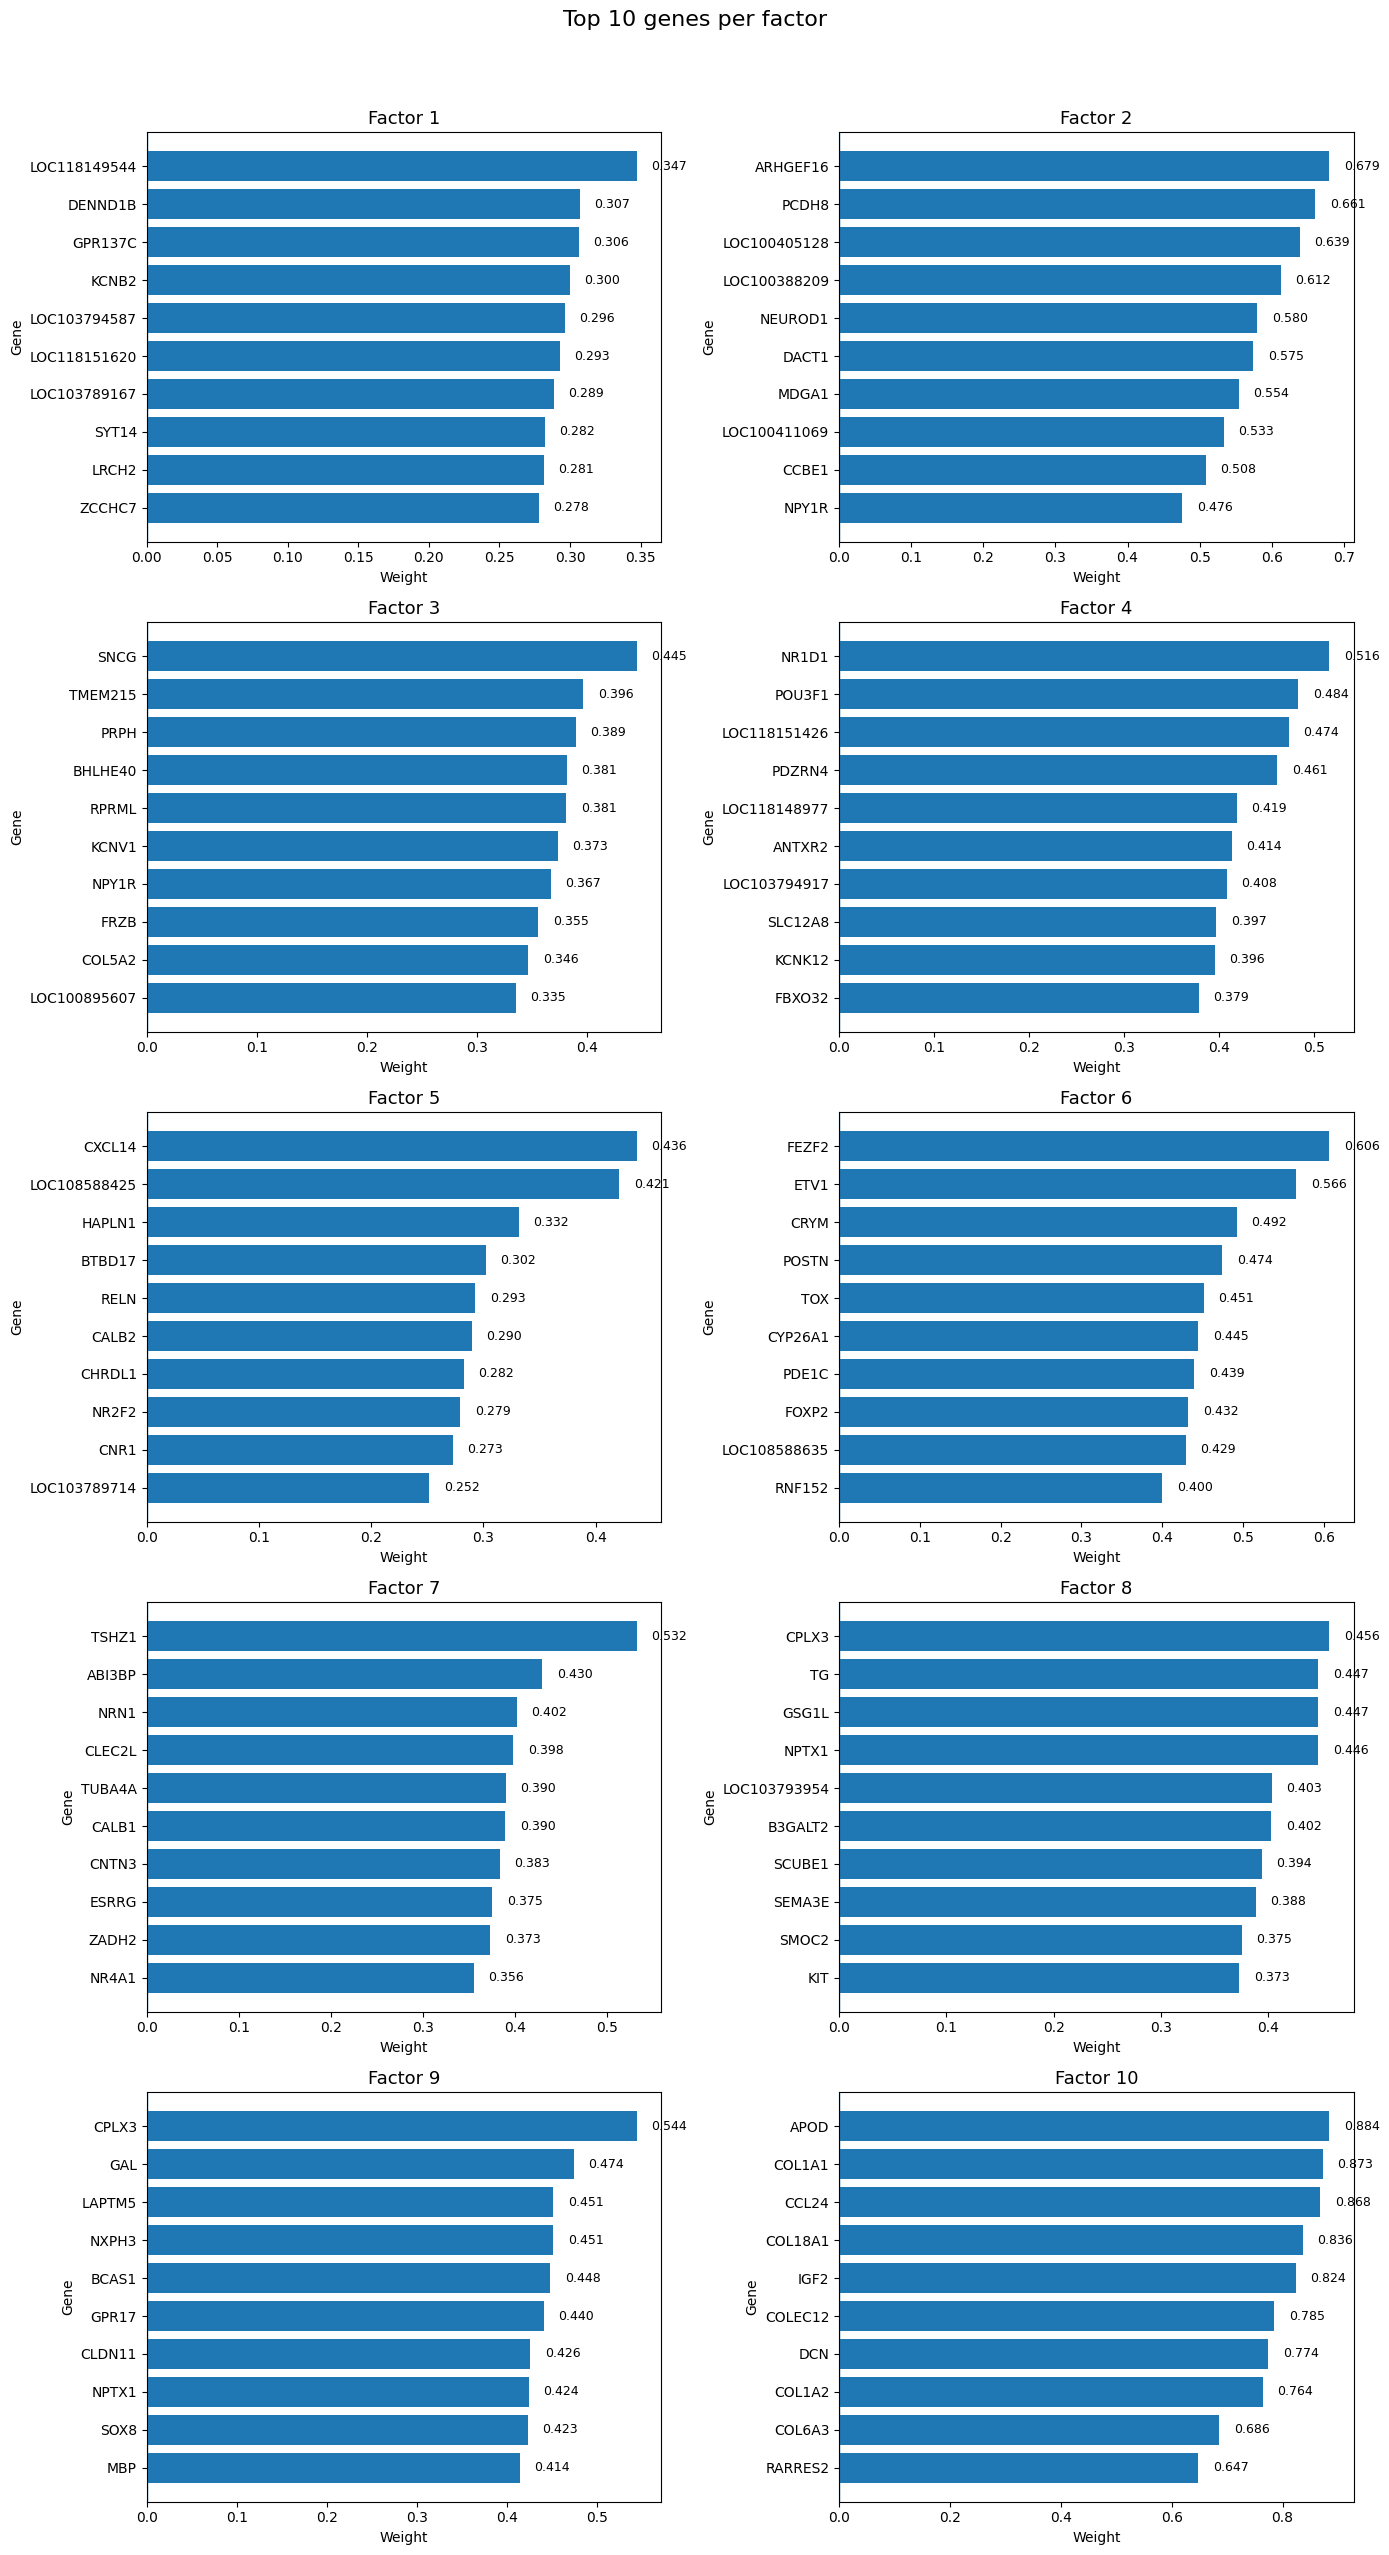

In [66]:
import pandas as pd


top_df = plot_top_genes_per_factor(
    data,
    top_n=10,
    gene_col="Unnamed: 0",
    sort_by_abs=False,
    ncols=2,
    title="Top 10 genes per factor",
    save_path="res/T1089-P0/T1089_P0_top10_genes_per_factor.png",
    dpi=300
)

In [67]:
import os
import glob
import math
import pandas as pd
import matplotlib.pyplot as plt


def get_top_genes_per_factor(
    data: pd.DataFrame,
    top_n: int = 10,
    gene_col: str = None,
    factor_cols: list = None,
    sort_by_abs: bool = False
) -> pd.DataFrame:
    df = data.copy()

    if gene_col is None:
        gene_col = df.columns[0]

    if factor_cols is None:
        factor_cols = [c for c in df.columns if c != gene_col]

    results = []

    for factor in factor_cols:
        tmp = df[[gene_col, factor]].copy()
        tmp.columns = ["gene", "weight"]

        if sort_by_abs:
            tmp = tmp.reindex(tmp["weight"].abs().sort_values(ascending=False).index)
        else:
            tmp = tmp.sort_values("weight", ascending=False)

        tmp = tmp.head(top_n).reset_index(drop=True)
        tmp["factor"] = str(factor)
        tmp["rank"] = range(1, len(tmp) + 1)

        results.append(tmp[["factor", "rank", "gene", "weight"]])

    return pd.concat(results, ignore_index=True)


def plot_top_genes_per_factor(
    data: pd.DataFrame,
    top_n: int = 10,
    gene_col: str = None,
    factor_cols: list = None,
    sort_by_abs: bool = False,
    ncols: int = 2,
    figsize_per_panel=(7, 5),
    title: str = "Top genes per factor",
    save_path: str = None,
    dpi: int = 300,
    show: bool = False
):
    top_df = get_top_genes_per_factor(
        data=data,
        top_n=top_n,
        gene_col=gene_col,
        factor_cols=factor_cols,
        sort_by_abs=sort_by_abs
    )

    factors = list(top_df["factor"].unique())
    n_factors = len(factors)
    nrows = math.ceil(n_factors / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows)
    )

    if n_factors == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, factor in zip(axes, factors):
        sub = top_df[top_df["factor"] == factor].copy()
        sub = sub.sort_values("weight", ascending=True)

        ax.barh(sub["gene"], sub["weight"])
        ax.set_title(f"Factor {factor}", fontsize=13)
        ax.set_xlabel("Weight")
        ax.set_ylabel("Gene")
        ax.axvline(0, linewidth=1)

        x_min, x_max = sub["weight"].min(), sub["weight"].max()
        scale = max(abs(x_min), abs(x_max))
        span = scale * 0.03 if scale > 0 else 0.01

        for _, row in sub.iterrows():
            x = row["weight"]
            y = row["gene"]
            if x >= 0:
                ax.text(x + span, y, f"{x:.3f}", va="center", fontsize=9)
            else:
                ax.text(x - span, y, f"{x:.3f}", va="center", ha="right", fontsize=9)

    for j in range(len(factors), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return top_df


def process_all_slices(
    res_dir: str = "res",
    pattern: str = "*_nsfh20_spde_loadings.csv",
    top_n: int = 10,
    gene_col: str = None,
    sort_by_abs: bool = False,
    save_pdf: bool = False,
    dpi: int = 300
) -> pd.DataFrame:
    """
    Ищет все loadings-файлы в res/*/ и для каждого сохраняет:
      - *_top{top_n}_genes_per_factor.csv
      - *_top{top_n}_genes_per_factor.png
      - optionally *.pdf

    Возвращает объединенный DataFrame по всем слайсам.
    """
    search_pattern = os.path.join(res_dir, "*", pattern)
    csv_files = sorted(glob.glob(search_pattern))

    if len(csv_files) == 0:
        raise ValueError(f"Не найдено файлов по шаблону: {search_pattern}")

    all_results = []

    print(f"Found {len(csv_files)} files")

    for csv_path in csv_files:
        try:
            print(f"Processing: {csv_path}")
            data = pd.read_csv(csv_path)

            slice_name = os.path.basename(os.path.dirname(csv_path))
            base_name = os.path.splitext(os.path.basename(csv_path))[0]

            top_df = get_top_genes_per_factor(
                data=data,
                top_n=top_n,
                gene_col=gene_col,
                sort_by_abs=sort_by_abs
            )
            top_df["slice"] = slice_name

            out_csv = os.path.join(
                os.path.dirname(csv_path),
                f"{base_name}_top{top_n}_genes_per_factor.csv"
            )
            top_df.to_csv(out_csv, index=False)

            out_png = os.path.join(
                os.path.dirname(csv_path),
                f"{base_name}_top{top_n}_genes_per_factor.png"
            )
            plot_top_genes_per_factor(
                data=data,
                top_n=top_n,
                gene_col=gene_col,
                sort_by_abs=sort_by_abs,
                ncols=2,
                title=f"{slice_name}: Top {top_n} genes per factor",
                save_path=out_png,
                dpi=dpi,
                show=False
            )

            if save_pdf:
                out_pdf = os.path.join(
                    os.path.dirname(csv_path),
                    f"{base_name}_top{top_n}_genes_per_factor.pdf"
                )
                plot_top_genes_per_factor(
                    data=data,
                    top_n=top_n,
                    gene_col=gene_col,
                    sort_by_abs=sort_by_abs,
                    ncols=2,
                    title=f"{slice_name}: Top {top_n} genes per factor",
                    save_path=out_pdf,
                    dpi=dpi,
                    show=False
                )

            all_results.append(top_df)

        except Exception as e:
            print(f"Error in {csv_path}: {e}")

    if len(all_results) == 0:
        raise ValueError("Не удалось обработать ни одного файла")

    combined = pd.concat(all_results, ignore_index=True)

    combined_out = os.path.join(
        res_dir,
        f"all_slices_top{top_n}_genes_per_factor.csv"
    )
    combined.to_csv(combined_out, index=False)

    print(f"Saved combined table: {combined_out}")
    return combined

In [78]:
combined_top = process_all_slices(
    res_dir="res_2000",
    pattern="*_nsfh20_spde_loadings.csv",
    top_n=10,
    gene_col="Unnamed: 0",
    sort_by_abs=False,
    save_pdf=False,
    dpi=300
)

Found 6 files
Processing: res_2000/T1089_MT66_P0/T1089_MT66_P0_nsfh20_spde_loadings.csv
Processing: res_2000/T1090_MT65_P0/T1090_MT65_P0_nsfh20_spde_loadings.csv
Processing: res_2000/T1091_MT64_P32/T1091_MT64_P32_nsfh20_spde_loadings.csv
Processing: res_2000/T1092_MT63_P32/T1092_MT63_P32_nsfh20_spde_loadings.csv
Processing: res_2000/T1098_MT69_3M/T1098_MT69_3M_nsfh20_spde_loadings.csv
Processing: res_2000/T1099_MT67_7M/T1099_MT67_7M_nsfh20_spde_loadings.csv
Saved combined table: res_2000/all_slices_top10_genes_per_factor.csv


In [79]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt


def load_all_loading_tables(
    res_dir="res",
    pattern="*_nsfh20_spde_loadings.csv",
    gene_col="Unnamed: 0"
):
    """
    Загружает все loading tables из res/*/
    Возвращает dict:
        {slice_name: dataframe}
    """
    files = sorted(glob.glob(os.path.join(res_dir, "*", pattern)))
    if not files:
        raise ValueError(f"Не найдено файлов по шаблону: {os.path.join(res_dir, '*', pattern)}")

    tables = {}
    for path in files:
        slice_name = os.path.basename(os.path.dirname(path))
        df = pd.read_csv(path)
        if gene_col not in df.columns:
            raise ValueError(f"Колонка {gene_col} не найдена в {path}")
        tables[slice_name] = df

    return tables

In [80]:
def get_top_genes_for_factor(df, factor, gene_col="Unnamed: 0", top_n=10, sort_by_abs=False):
    tmp = df[[gene_col, factor]].copy()
    tmp.columns = ["gene", "weight"]

    if sort_by_abs:
        tmp = tmp.reindex(tmp["weight"].abs().sort_values(ascending=False).index)
    else:
        tmp = tmp.sort_values("weight", ascending=False)

    return tmp.head(top_n)


def get_intersection_top_genes_across_slices(
    tables,
    gene_col="Unnamed: 0",
    top_n=10,
    sort_by_abs=False
):
    """
    Для каждого фактора считает пересечение top_n генов по всем слайсам.

    Возвращает dict:
        {
          factor1: [geneA, geneB, ...],
          factor2: [...],
          ...
        }
    """
    slice_names = list(tables.keys())
    first_df = tables[slice_names[0]]

    factor_cols = [c for c in first_df.columns if c != gene_col]
    intersections = {}

    for factor in factor_cols:
        top_sets = []
        for slice_name, df in tables.items():
            top_df = get_top_genes_for_factor(
                df=df,
                factor=factor,
                gene_col=gene_col,
                top_n=top_n,
                sort_by_abs=sort_by_abs
            )
            top_sets.append(set(top_df["gene"]))

        common_genes = set.intersection(*top_sets) if top_sets else set()
        intersections[factor] = sorted(common_genes)

    return intersections

In [81]:
def collect_gene_weights_across_slices(
    tables,
    factor,
    gene,
    gene_col="Unnamed: 0",
    slice_order=None
):
    """
    Возвращает DataFrame:
        slice | weight
    """
    rows = []

    if slice_order is None:
        slice_order = sorted(tables.keys())

    for slice_name in slice_order:
        df = tables[slice_name]
        sub = df[df[gene_col] == gene]

        if len(sub) == 0:
            weight = None
        else:
            weight = sub[factor].iloc[0]

        rows.append({
            "slice": slice_name,
            "gene": gene,
            "factor": factor,
            "weight": weight
        })

    return pd.DataFrame(rows)

In [82]:
def plot_intersection_genes_for_factor(
    tables,
    factor,
    genes,
    gene_col="Unnamed: 0",
    slice_order=None,
    save_dir=None,
    figsize=(10, 5)
):
    """
    Для одного фактора строит по одному графику на каждый gene из списка genes.
    """
    if slice_order is None:
        slice_order = sorted(tables.keys())

    if len(genes) == 0:
        print(f"Для фактора {factor} пересечение пустое")
        return

    for gene in genes:
        weights_df = collect_gene_weights_across_slices(
            tables=tables,
            factor=factor,
            gene=gene,
            gene_col=gene_col,
            slice_order=slice_order
        )

        plt.figure(figsize=figsize)
        plt.plot(weights_df["slice"], weights_df["weight"], marker="o")
        plt.title(f"Factor {factor}: {gene}")
        plt.xlabel("Slice")
        plt.ylabel("Weight")
        plt.xticks(rotation=45, ha="right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        if save_dir is not None:
            os.makedirs(save_dir, exist_ok=True)
            out_path = os.path.join(save_dir, f"factor_{factor}_gene_{gene}.png")
            plt.savefig(out_path, dpi=300, bbox_inches="tight")

        plt.show()
        plt.close()

In [83]:
def plot_all_intersection_genes_one_factor(
    tables,
    factor,
    genes,
    gene_col="Unnamed: 0",
    slice_order=None,
    save_path=None,
    figsize=(12, 6)
):
    """
    Один график для фактора, где каждая линия = один общий gene.
    """
    if slice_order is None:
        slice_order = sorted(tables.keys())

    if len(genes) == 0:
        print(f"Для фактора {factor} пересечение пустое")
        return

    plt.figure(figsize=figsize)

    for gene in genes:
        weights_df = collect_gene_weights_across_slices(
            tables=tables,
            factor=factor,
            gene=gene,
            gene_col=gene_col,
            slice_order=slice_order
        )
        plt.plot(weights_df["slice"], weights_df["weight"], marker="o", label=gene)

    plt.title(f"Common top genes across slices — factor {factor}")
    plt.xlabel("Slice")
    plt.ylabel("Weight")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

In [84]:
def plot_intersections_for_all_factors(
    res_dir="res",
    pattern="*_nsfh20_spde_loadings.csv",
    gene_col="Unnamed: 0",
    top_n=10,
    sort_by_abs=False,
    save_dir="res/intersection_plots"
):
    tables = load_all_loading_tables(
        res_dir=res_dir,
        pattern=pattern,
        gene_col=gene_col
    )

    intersections = get_intersection_top_genes_across_slices(
        tables=tables,
        gene_col=gene_col,
        top_n=top_n,
        sort_by_abs=sort_by_abs
    )

    slice_order = sorted(tables.keys())

    summary_rows = []

    for factor, genes in intersections.items():
        summary_rows.append({
            "factor": factor,
            "n_common_genes": len(genes),
            "genes": ", ".join(genes)
        })

        print(f"Factor {factor}: {len(genes)} common genes")
        if genes:
            print("   ", genes)

        out_path = None
        if save_dir is not None:
            os.makedirs(save_dir, exist_ok=True)
            out_path = os.path.join(save_dir, f"factor_{factor}_common_top_genes.png")

        plot_all_intersection_genes_one_factor(
            tables=tables,
            factor=factor,
            genes=genes,
            gene_col=gene_col,
            slice_order=slice_order,
            save_path=out_path,
            figsize=(12, 6)
        )

    summary_df = pd.DataFrame(summary_rows)

    if save_dir is not None:
        summary_csv = os.path.join(save_dir, "common_genes_summary.csv")
        summary_df.to_csv(summary_csv, index=False)

    return intersections, summary_df

In [85]:
intersections, summary_df = plot_intersections_for_all_factors(
    res_dir="res_2000",
    pattern="*_nsfh20_spde_loadings.csv",
    gene_col="Unnamed: 0",
    top_n=20,
    sort_by_abs=False,
    save_dir="res_2000/intersection_plots"
)

Factor 1: 0 common genes
Для фактора 1 пересечение пустое
Factor 2: 0 common genes
Для фактора 2 пересечение пустое
Factor 3: 0 common genes
Для фактора 3 пересечение пустое
Factor 4: 0 common genes
Для фактора 4 пересечение пустое
Factor 5: 0 common genes
Для фактора 5 пересечение пустое
Factor 6: 0 common genes
Для фактора 6 пересечение пустое
Factor 7: 0 common genes
Для фактора 7 пересечение пустое
Factor 8: 0 common genes
Для фактора 8 пересечение пустое
Factor 9: 0 common genes
Для фактора 9 пересечение пустое
Factor 10: 0 common genes
Для фактора 10 пересечение пустое


In [86]:
import os
import glob
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt


def load_all_loading_tables(
    res_dir="res",
    pattern="*_nsfh20_spde_loadings.csv",
    gene_col="Unnamed: 0"
):
    files = sorted(glob.glob(os.path.join(res_dir, "*", pattern)))
    if not files:
        raise ValueError(f"Не найдено файлов по шаблону: {os.path.join(res_dir, '*', pattern)}")

    tables = {}
    for path in files:
        slice_name = os.path.basename(os.path.dirname(path))
        df = pd.read_csv(path)
        if gene_col not in df.columns:
            raise ValueError(f"Колонка {gene_col} не найдена в {path}")
        tables[slice_name] = df

    return tables


def get_top_genes_for_factor(df, factor, gene_col="Unnamed: 0", top_n=10, sort_by_abs=False):
    tmp = df[[gene_col, factor]].copy()
    tmp.columns = ["gene", "weight"]

    if sort_by_abs:
        tmp = tmp.reindex(tmp["weight"].abs().sort_values(ascending=False).index)
    else:
        tmp = tmp.sort_values("weight", ascending=False)

    return tmp.head(top_n).reset_index(drop=True)


def get_genes_in_top_k_of_n_slices(
    tables,
    gene_col="Unnamed: 0",
    top_n=10,
    min_slices=3,
    sort_by_abs=False
):
    """
    Для каждого фактора находит гены, которые входят в top_n
    хотя бы в min_slices слайсах.

    Возвращает:
      selected_genes: dict[factor] = list of genes
      stats_df: DataFrame со статистикой
    """
    slice_names = list(tables.keys())
    first_df = tables[slice_names[0]]
    factor_cols = [c for c in first_df.columns if c != gene_col]

    selected_genes = {}
    stats_rows = []

    for factor in factor_cols:
        gene_counter = Counter()

        for slice_name, df in tables.items():
            top_df = get_top_genes_for_factor(
                df=df,
                factor=factor,
                gene_col=gene_col,
                top_n=top_n,
                sort_by_abs=sort_by_abs
            )
            gene_counter.update(top_df["gene"].tolist())

        genes_ok = sorted([gene for gene, cnt in gene_counter.items() if cnt >= min_slices])
        selected_genes[factor] = genes_ok

        for gene, cnt in gene_counter.items():
            stats_rows.append({
                "factor": str(factor),
                "gene": gene,
                "n_slices_in_top": cnt
            })

    stats_df = pd.DataFrame(stats_rows).sort_values(
        ["factor", "n_slices_in_top", "gene"],
        ascending=[True, False, True]
    ).reset_index(drop=True)

    return selected_genes, stats_df


def collect_gene_weights_across_slices(
    tables,
    factor,
    gene,
    gene_col="Unnamed: 0",
    slice_order=None
):
    if slice_order is None:
        slice_order = sorted(tables.keys())

    rows = []
    for slice_name in slice_order:
        df = tables[slice_name]
        sub = df[df[gene_col] == gene]

        weight = sub[factor].iloc[0] if len(sub) > 0 else None

        rows.append({
            "slice": slice_name,
            "factor": str(factor),
            "gene": gene,
            "weight": weight
        })

    return pd.DataFrame(rows)


def plot_selected_genes_for_factor(
    tables,
    factor,
    genes,
    gene_col="Unnamed: 0",
    slice_order=None,
    save_path=None,
    figsize=(12, 6)
):
    if slice_order is None:
        slice_order = sorted(tables.keys())

    if len(genes) == 0:
        print(f"Для фактора {factor} нет генов, проходящих порог")
        return

    plt.figure(figsize=figsize)

    for gene in genes:
        weights_df = collect_gene_weights_across_slices(
            tables=tables,
            factor=factor,
            gene=gene,
            gene_col=gene_col,
            slice_order=slice_order
        )
        plt.plot(weights_df["slice"], weights_df["weight"], marker="o", label=gene)

    plt.title(f"Factor {factor}: genes in top across at least selected slices")
    plt.xlabel("Slice")
    plt.ylabel("Weight")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()


def plot_top_genes_present_in_at_least_k_slices(
    res_dir="res",
    pattern="*_nsfh20_spde_loadings.csv",
    gene_col="Unnamed: 0",
    top_n=10,
    min_slices=3,
    sort_by_abs=False,
    save_dir="res/top_genes_at_least_k_slices"
):
    """
    Главная функция:
    - загружает все таблицы
    - находит для каждого фактора гены, входящие в top_n хотя бы в min_slices
    - строит графики по факторам
    - сохраняет summary и длинную таблицу весов
    """
    tables = load_all_loading_tables(
        res_dir=res_dir,
        pattern=pattern,
        gene_col=gene_col
    )

    n_total = len(tables)
    if min_slices > n_total:
        raise ValueError(f"min_slices={min_slices} больше числа слайсов n={n_total}")

    selected_genes, stats_df = get_genes_in_top_k_of_n_slices(
        tables=tables,
        gene_col=gene_col,
        top_n=top_n,
        min_slices=min_slices,
        sort_by_abs=sort_by_abs
    )

    slice_order = sorted(tables.keys())
    os.makedirs(save_dir, exist_ok=True)

    summary_rows = []
    all_weights_rows = []

    for factor, genes in selected_genes.items():
        summary_rows.append({
            "factor": str(factor),
            "n_genes_selected": len(genes),
            "genes": ", ".join(genes)
        })

        print(f"Factor {factor}: selected {len(genes)} genes")

        for gene in genes:
            weights_df = collect_gene_weights_across_slices(
                tables=tables,
                factor=factor,
                gene=gene,
                gene_col=gene_col,
                slice_order=slice_order
            )
            all_weights_rows.append(weights_df)

        out_path = os.path.join(
            save_dir,
            f"factor_{factor}_top{top_n}_present_in_at_least_{min_slices}_of_{n_total}.png"
        )

        plot_selected_genes_for_factor(
            tables=tables,
            factor=factor,
            genes=genes,
            gene_col=gene_col,
            slice_order=slice_order,
            save_path=out_path,
            figsize=(12, 6)
        )

    summary_df = pd.DataFrame(summary_rows)

    summary_path = os.path.join(
        save_dir,
        f"summary_top{top_n}_present_in_at_least_{min_slices}_of_{n_total}.csv"
    )
    summary_df.to_csv(summary_path, index=False)

    stats_path = os.path.join(
        save_dir,
        f"gene_counts_top{top_n}_present_in_at_least_{min_slices}_of_{n_total}.csv"
    )
    stats_df.to_csv(stats_path, index=False)

    if all_weights_rows:
        all_weights_df = pd.concat(all_weights_rows, ignore_index=True)
    else:
        all_weights_df = pd.DataFrame(columns=["slice", "factor", "gene", "weight"])

    weights_path = os.path.join(
        save_dir,
        f"weights_top{top_n}_present_in_at_least_{min_slices}_of_{n_total}.csv"
    )
    all_weights_df.to_csv(weights_path, index=False)

    print(f"Saved summary: {summary_path}")
    print(f"Saved gene counts: {stats_path}")
    print(f"Saved weights: {weights_path}")

    return selected_genes, summary_df, stats_df, all_weights_df

Factor 1: selected 1 genes


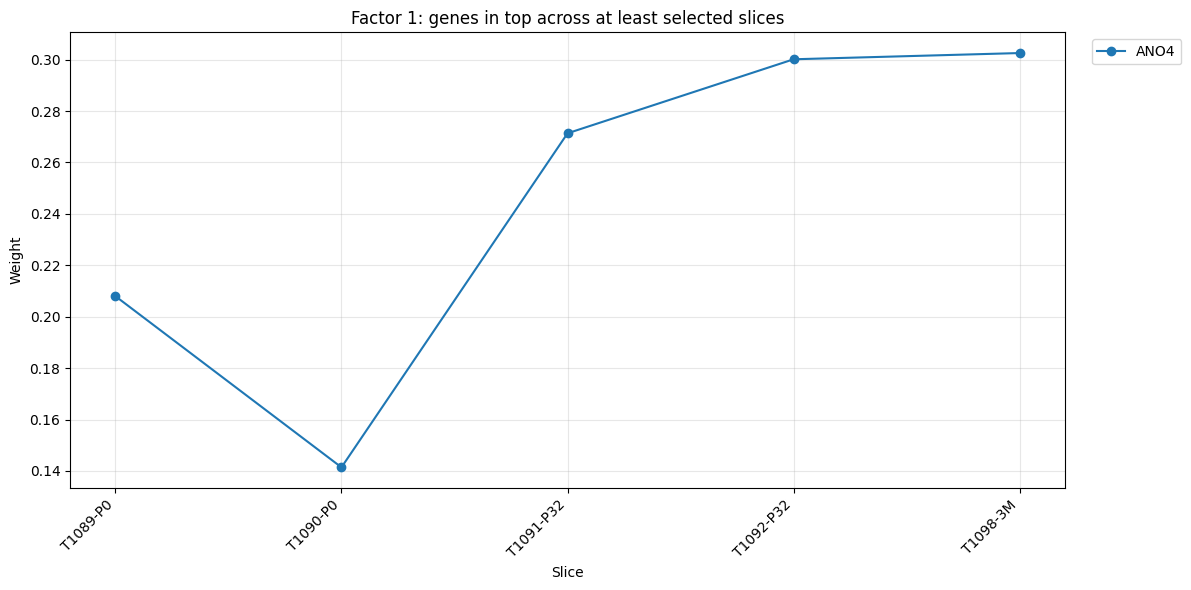

Factor 2: selected 4 genes


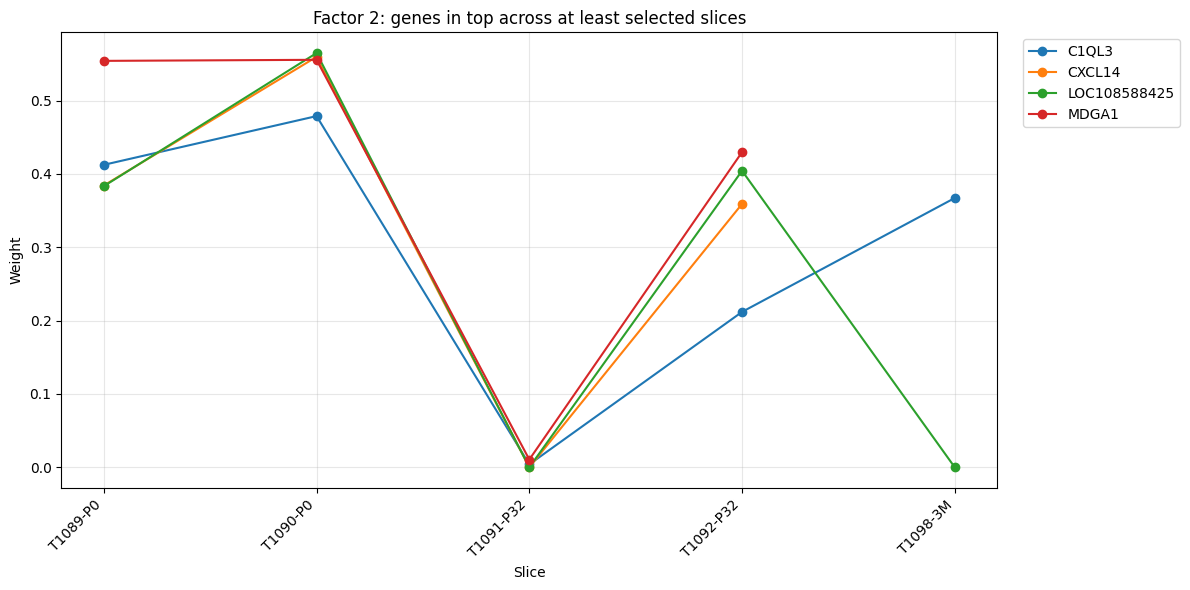

Factor 3: selected 1 genes


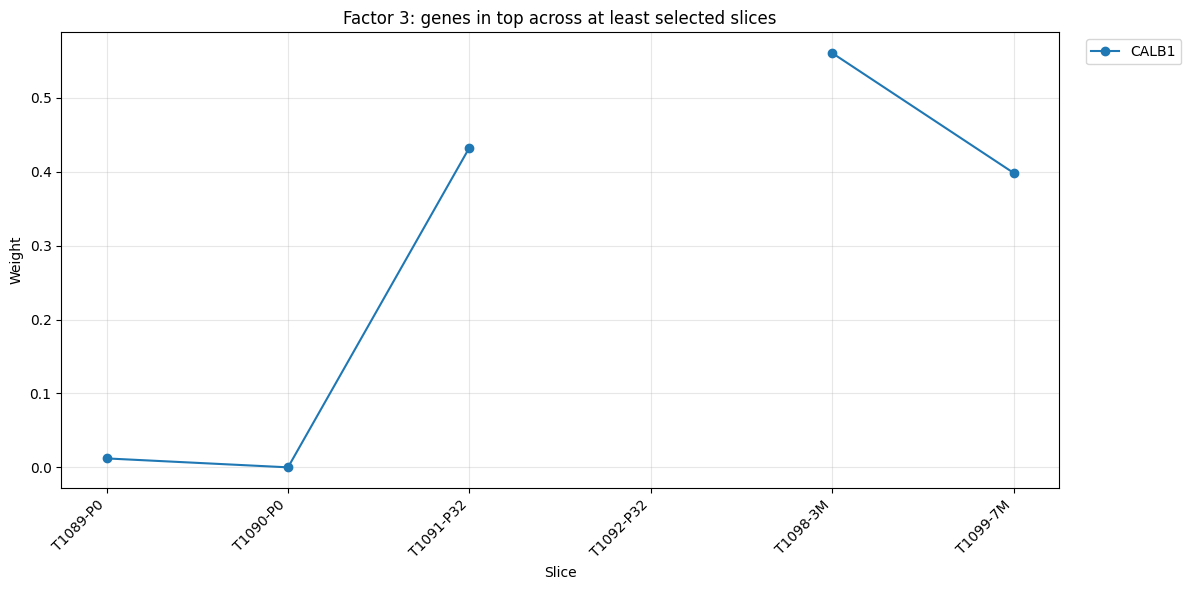

Factor 4: selected 2 genes


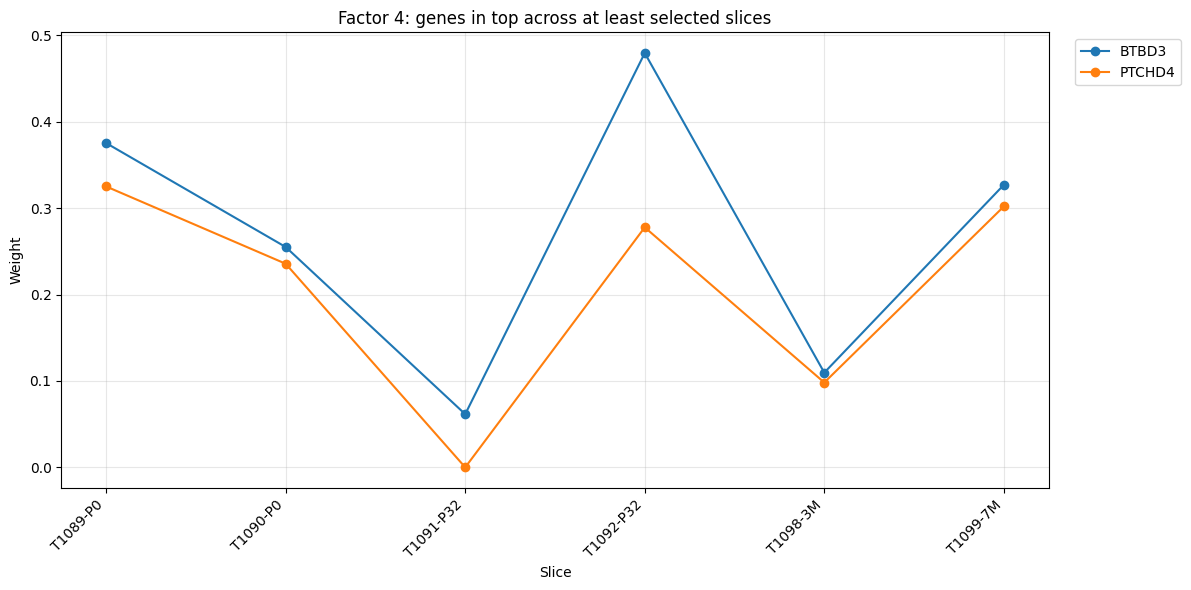

Factor 5: selected 1 genes


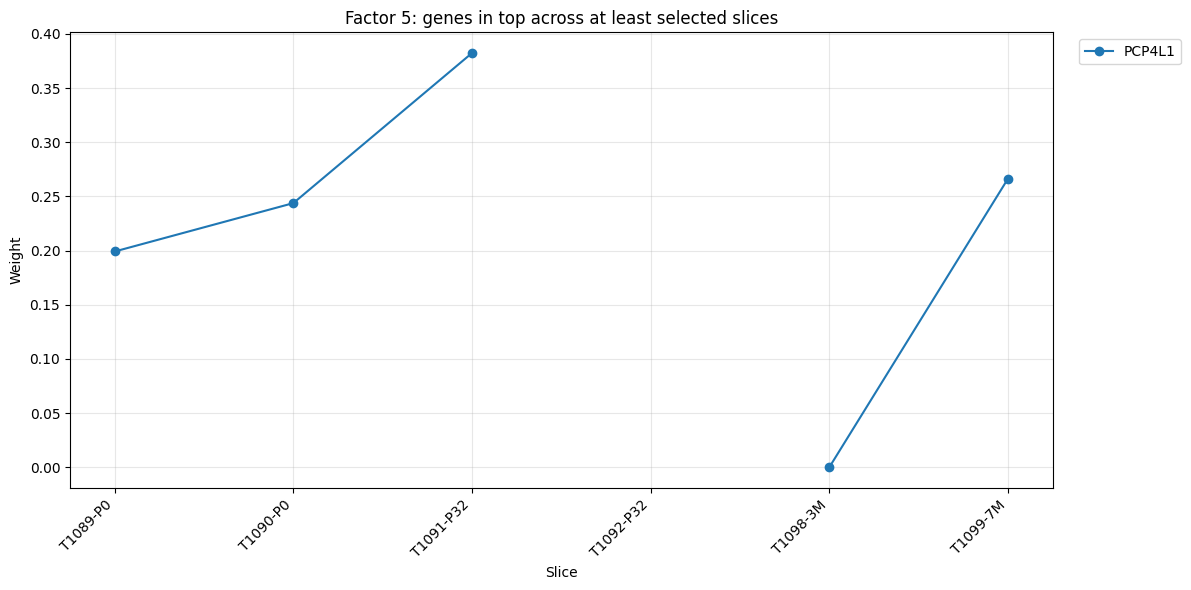

Factor 6: selected 0 genes
Для фактора 6 нет генов, проходящих порог
Factor 7: selected 0 genes
Для фактора 7 нет генов, проходящих порог
Factor 8: selected 1 genes


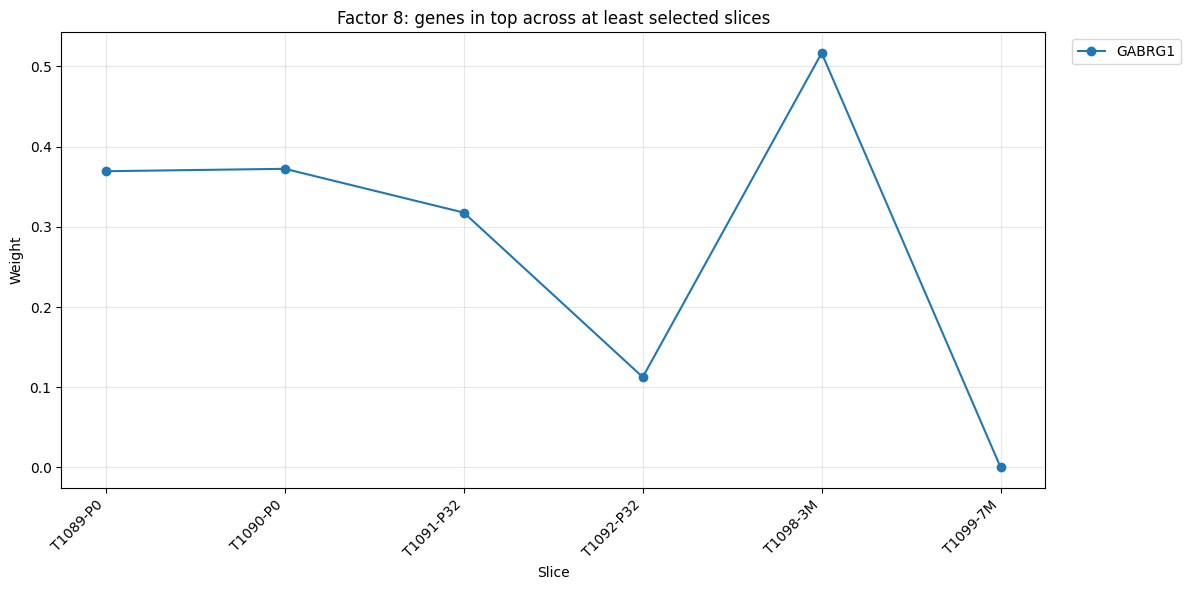

Factor 9: selected 1 genes


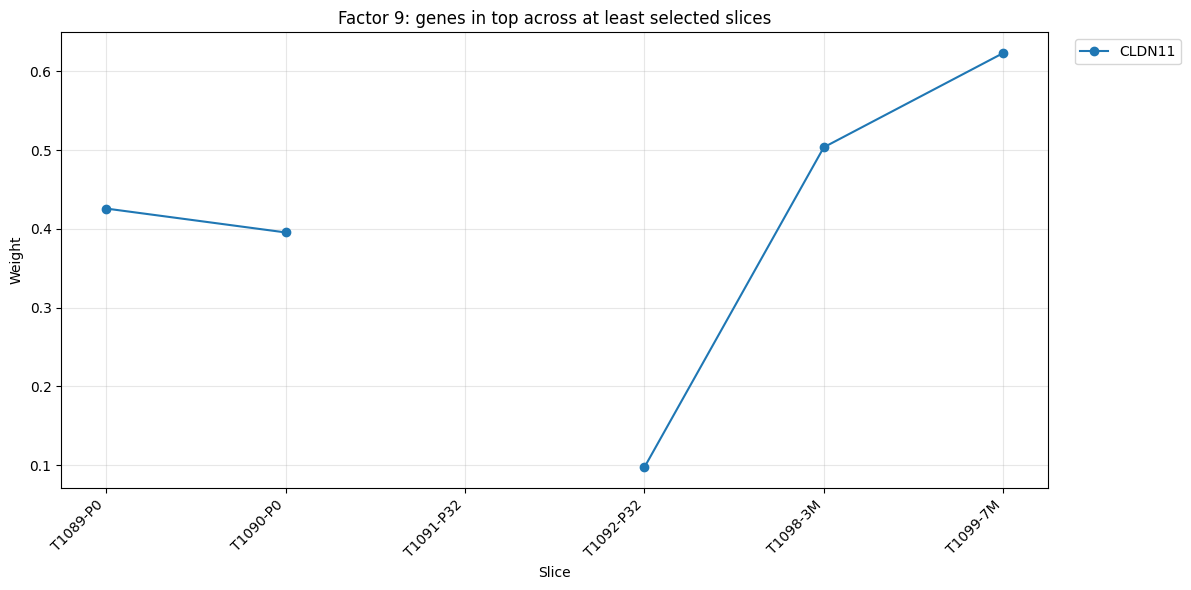

Factor 10: selected 15 genes


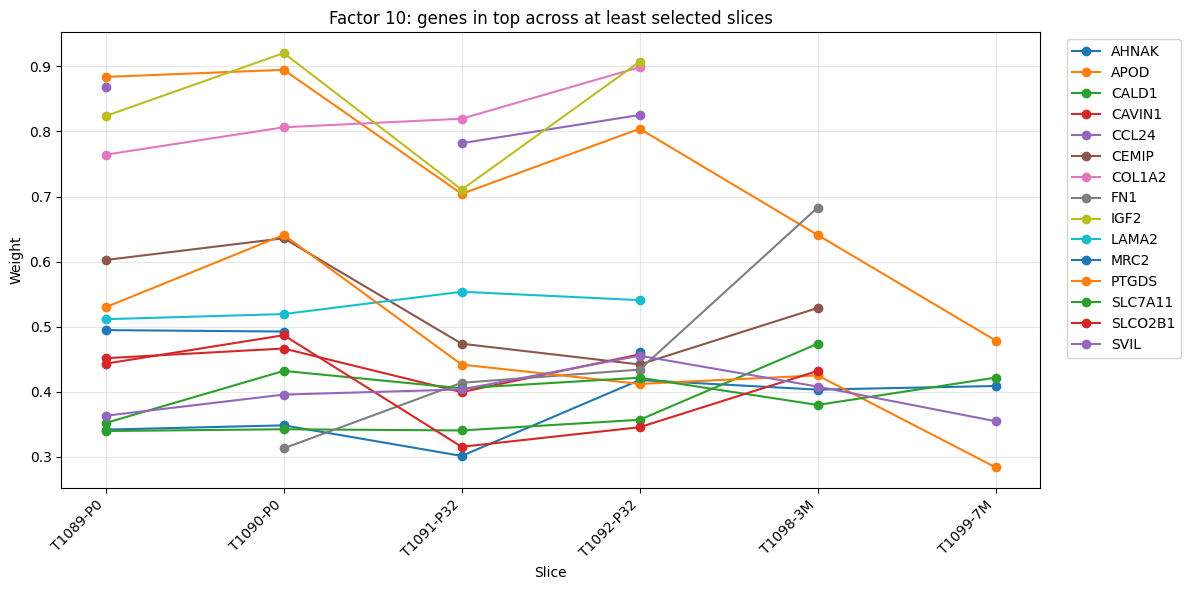

Saved summary: res/top20_genes_at_least_3_slices/summary_top20_present_in_at_least_3_of_6.csv
Saved gene counts: res/top20_genes_at_least_3_slices/gene_counts_top20_present_in_at_least_3_of_6.csv
Saved weights: res/top20_genes_at_least_3_slices/weights_top20_present_in_at_least_3_of_6.csv


In [89]:
selected_genes, summary_df, stats_df, all_weights_df = plot_top_genes_present_in_at_least_k_slices(
    res_dir="res",
    pattern="*_nsfh20_spde_loadings.csv",
    gene_col="Unnamed: 0",
    top_n=20,
    min_slices=3,
    sort_by_abs=False,
    save_dir="res/top20_genes_at_least_3_slices"
)

Factor 1: selected 3 genes


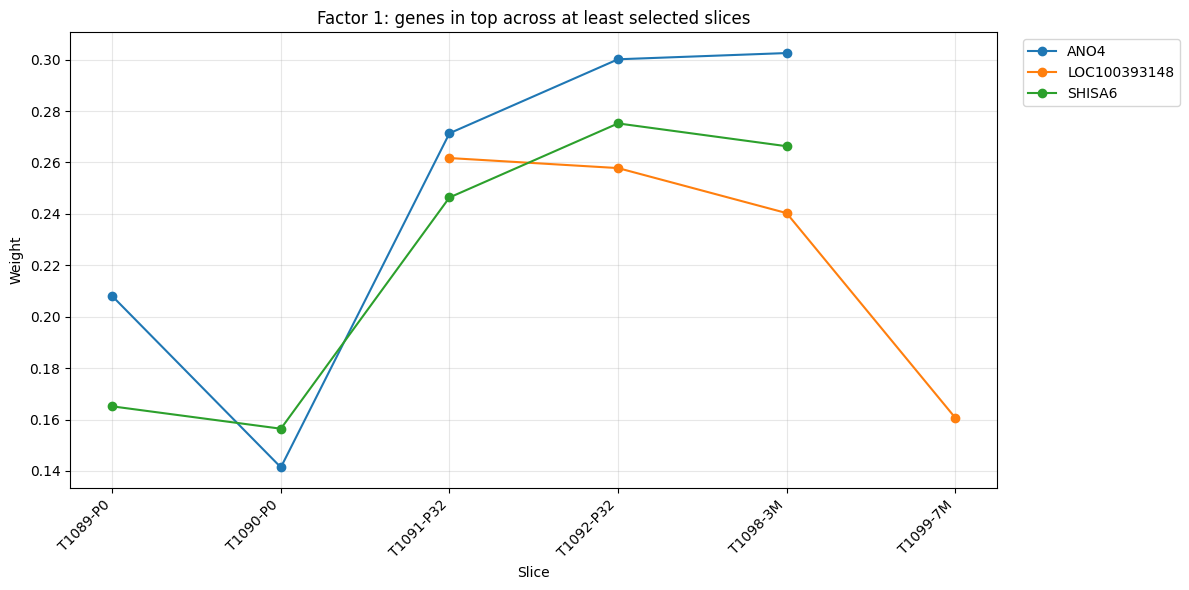

Factor 2: selected 9 genes


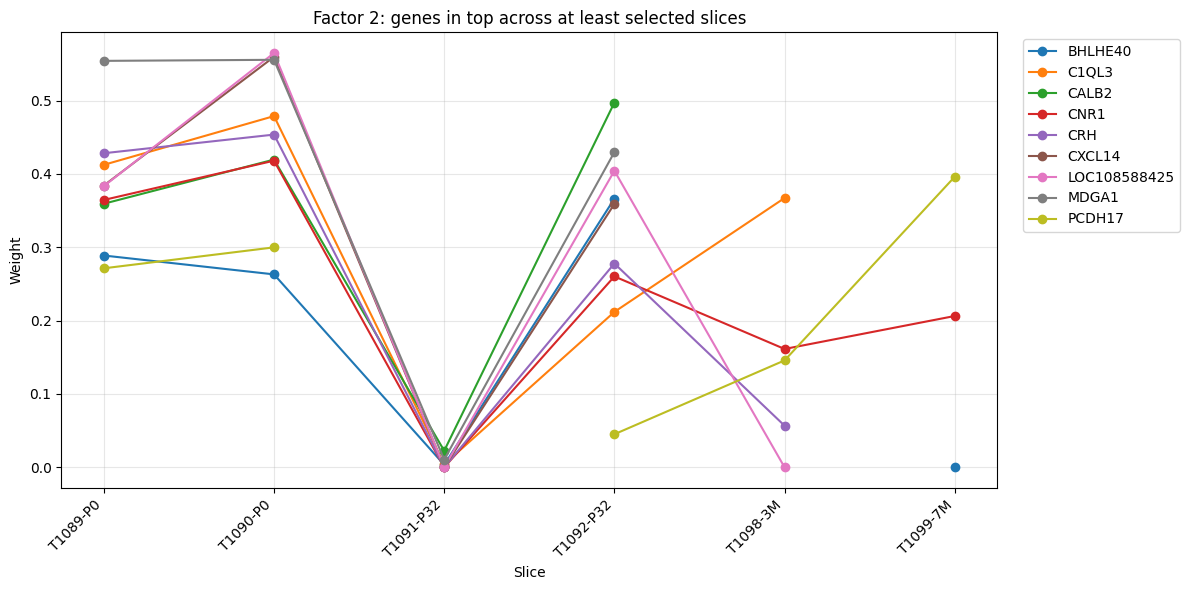

Factor 3: selected 7 genes


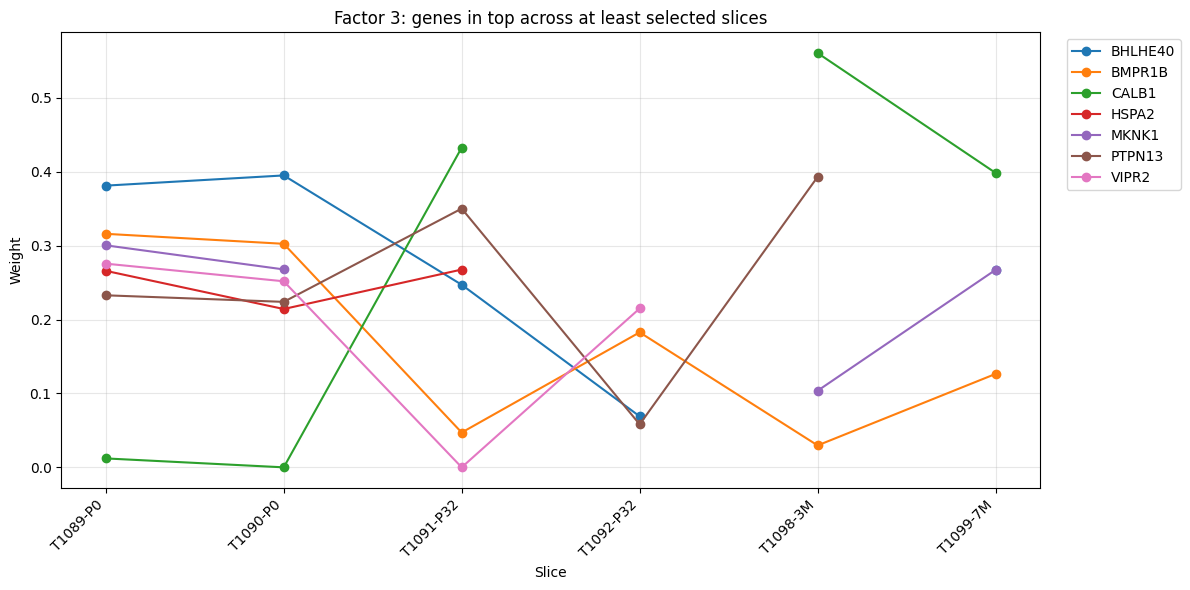

Factor 4: selected 6 genes


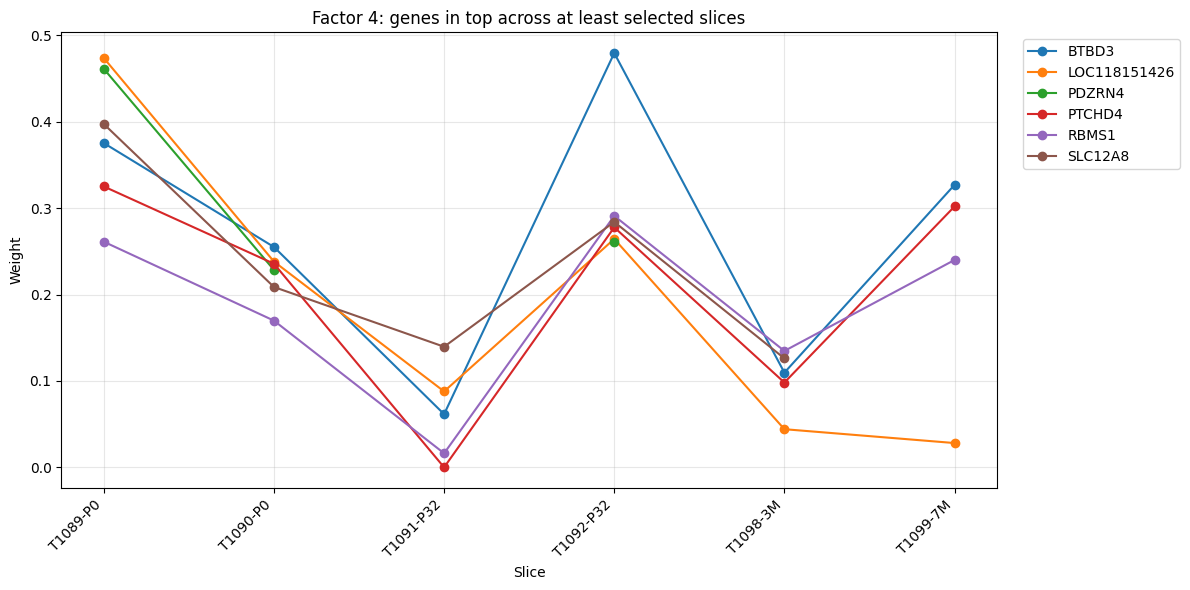

Factor 5: selected 3 genes


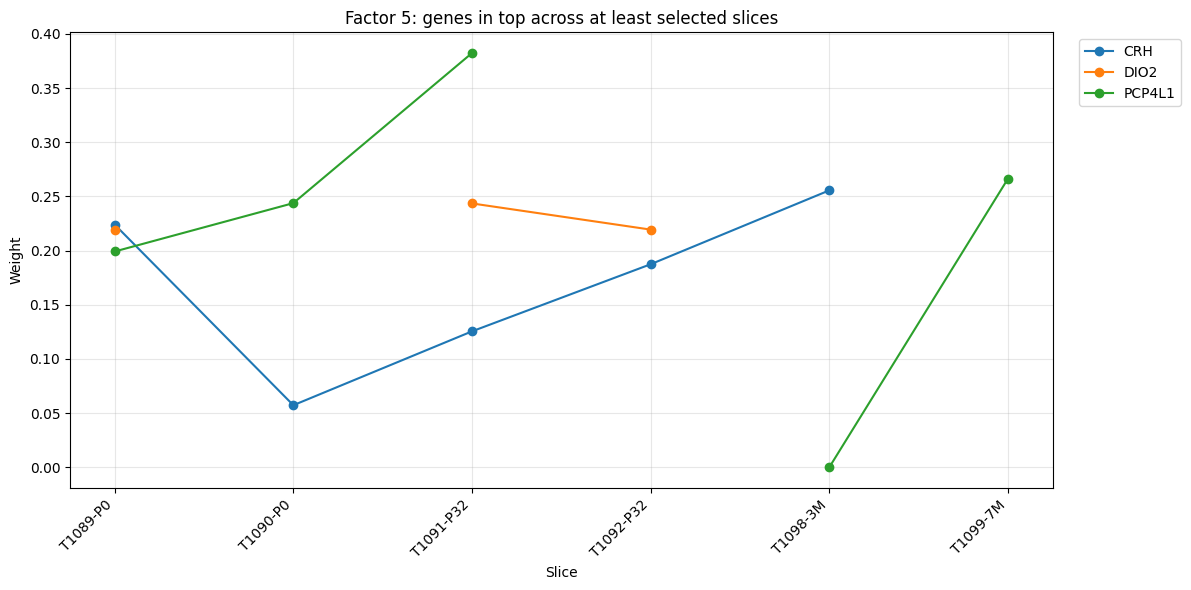

Factor 6: selected 5 genes


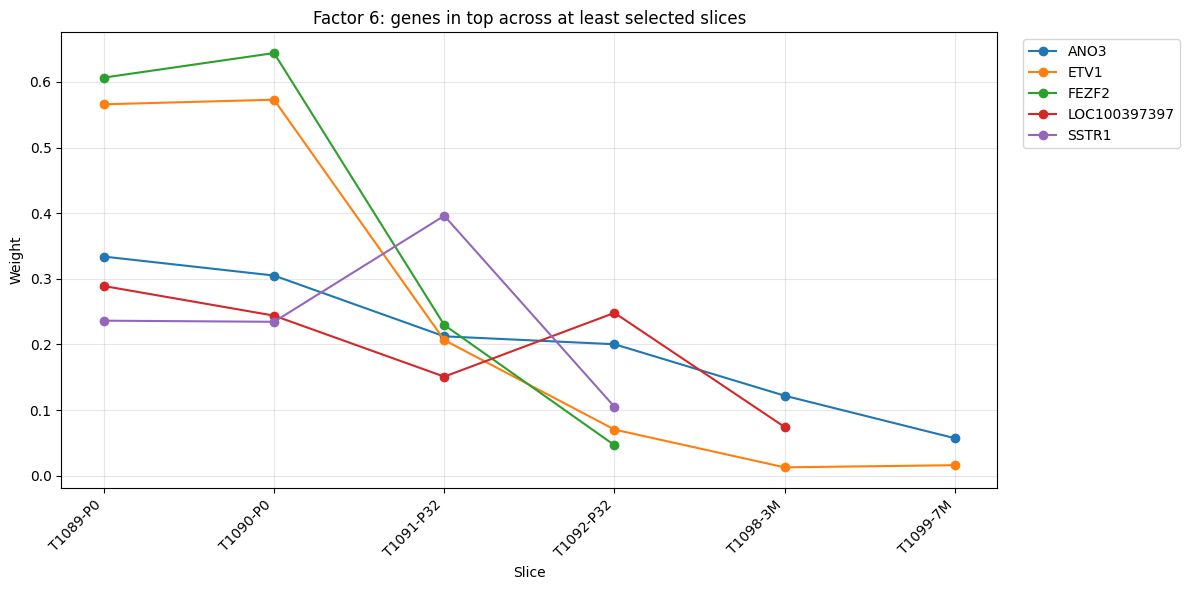

Factor 7: selected 3 genes


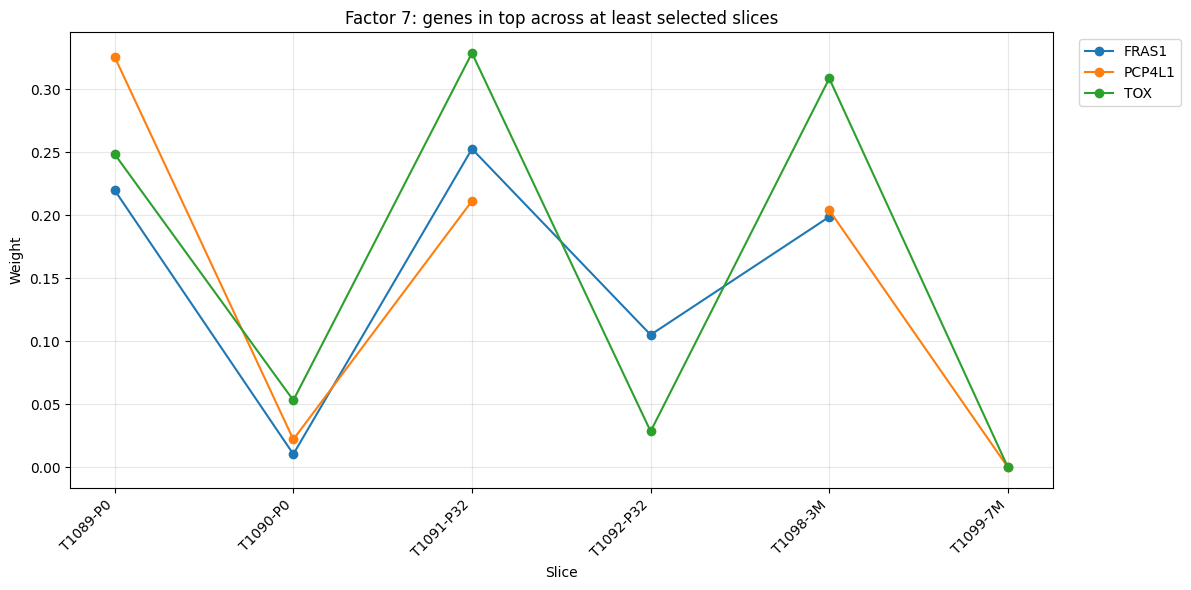

Factor 8: selected 3 genes


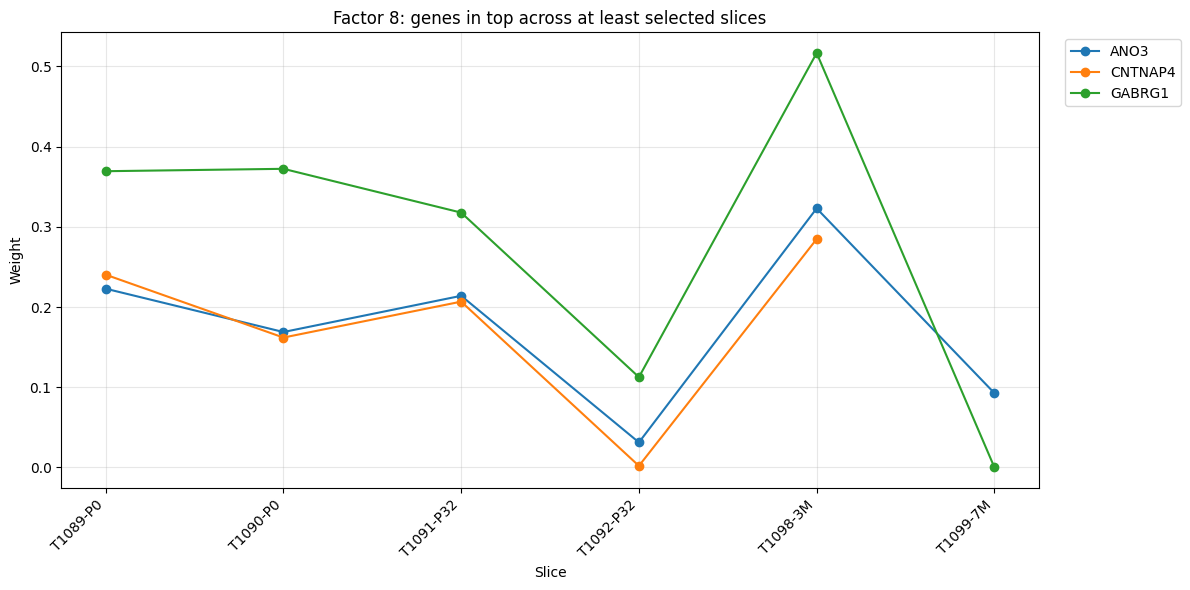

Factor 9: selected 9 genes


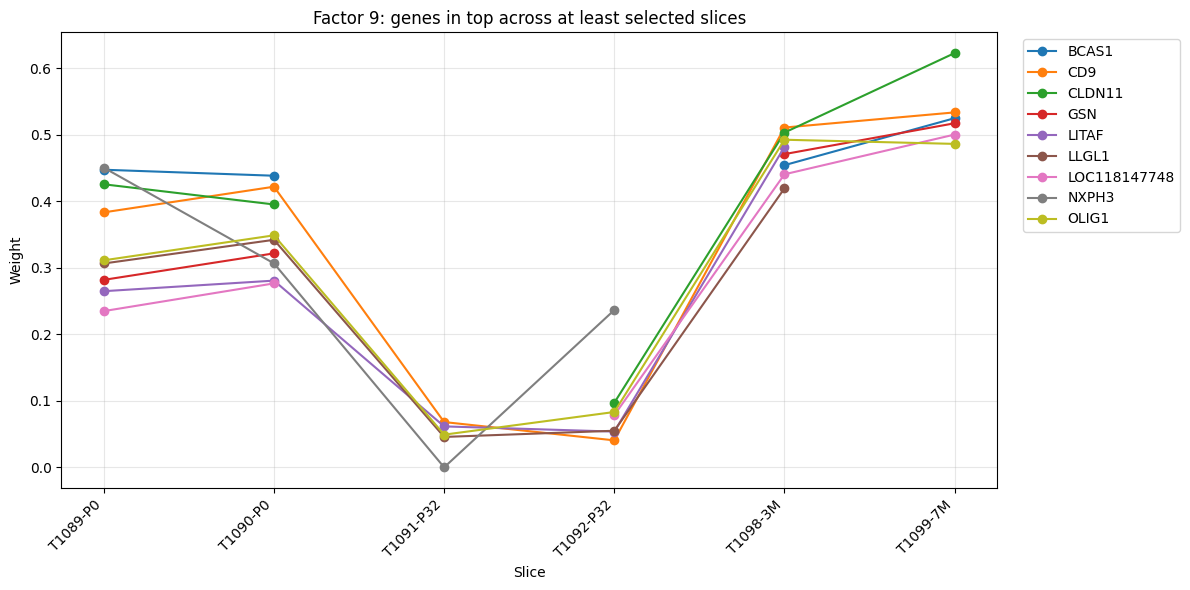

Factor 10: selected 36 genes


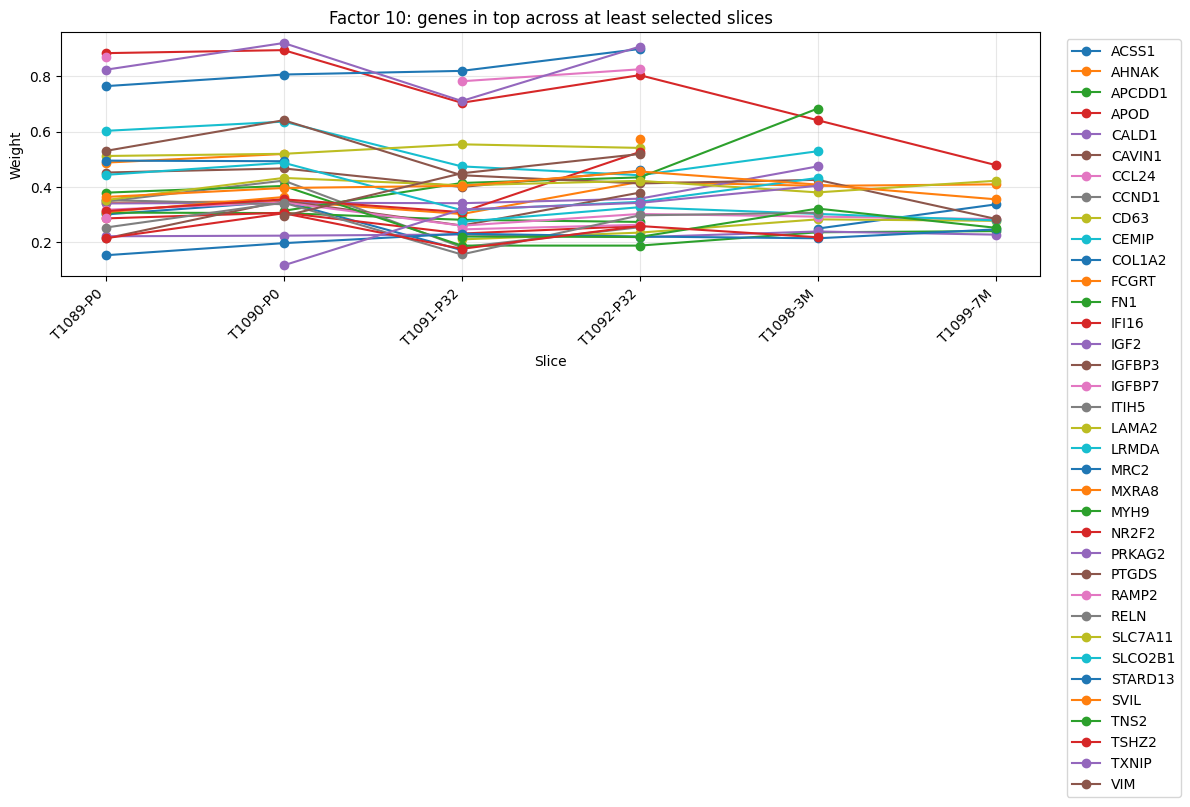

Saved summary: res/top50_genes_at_least_3_slices/summary_top50_present_in_at_least_3_of_6.csv
Saved gene counts: res/top50_genes_at_least_3_slices/gene_counts_top50_present_in_at_least_3_of_6.csv
Saved weights: res/top50_genes_at_least_3_slices/weights_top50_present_in_at_least_3_of_6.csv


In [90]:
selected_genes, summary_df, stats_df, all_weights_df = plot_top_genes_present_in_at_least_k_slices(
    res_dir="res",
    pattern="*_nsfh20_spde_loadings.csv",
    gene_col="Unnamed: 0",
    top_n=50,
    min_slices=3,
    sort_by_abs=False,
    save_dir="res/top50_genes_at_least_3_slices"
)

Factor 1: selected 3 genes


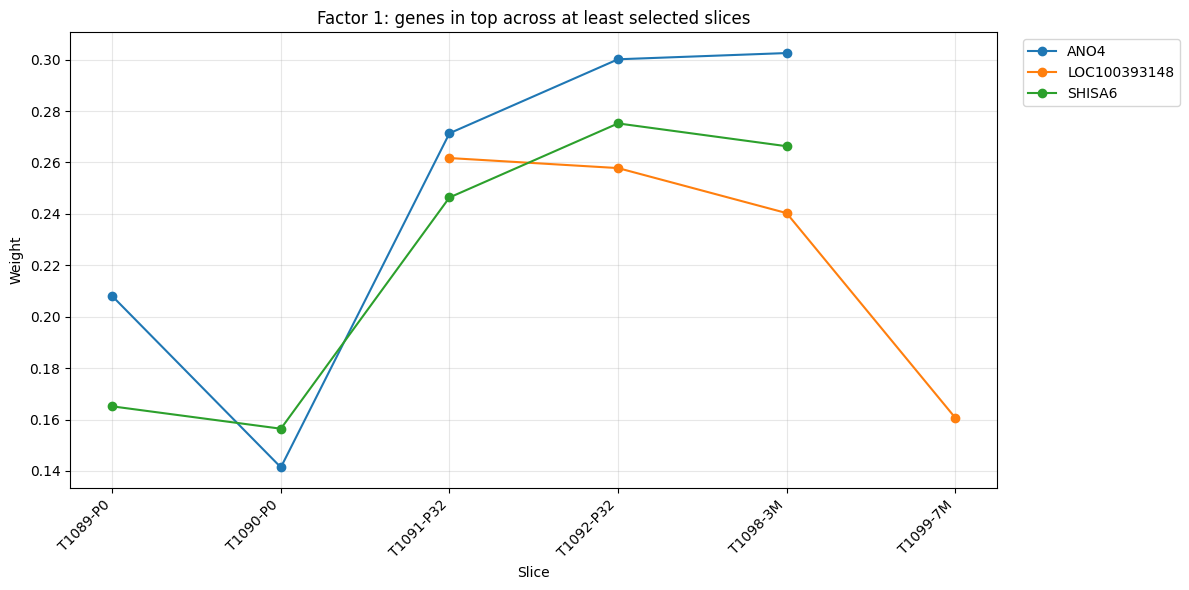

Factor 2: selected 9 genes


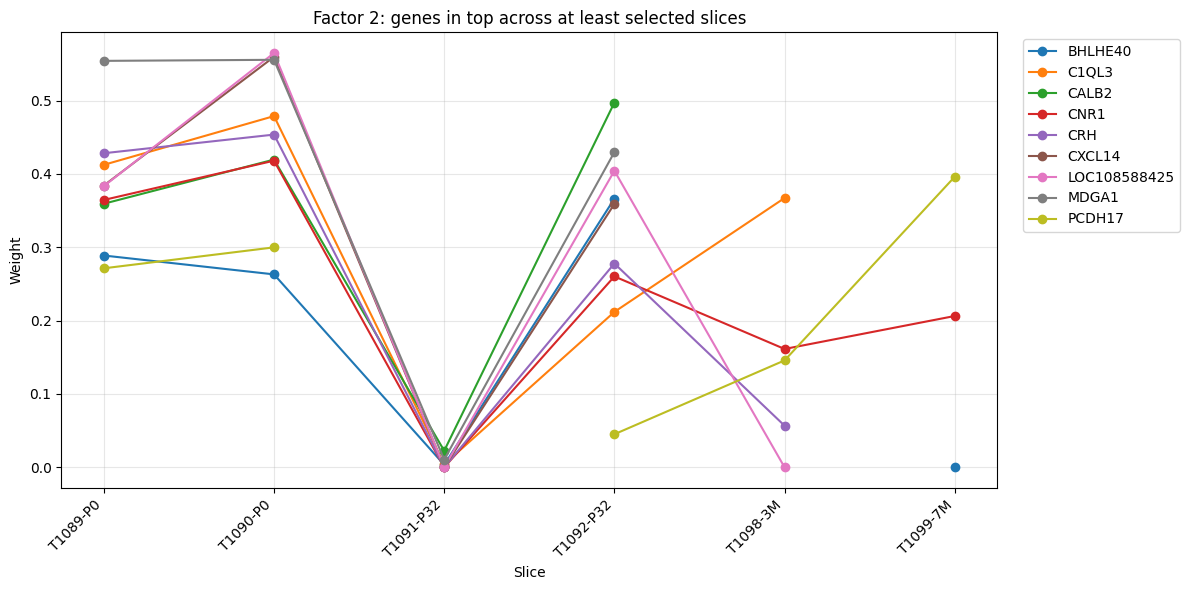

Factor 3: selected 7 genes


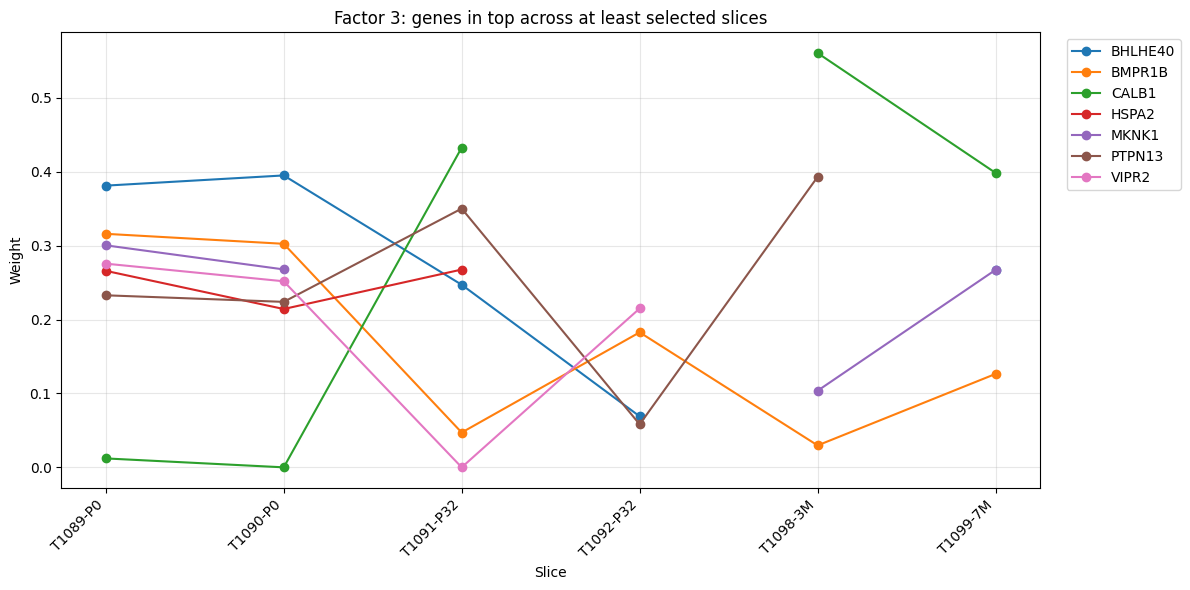

Factor 4: selected 6 genes


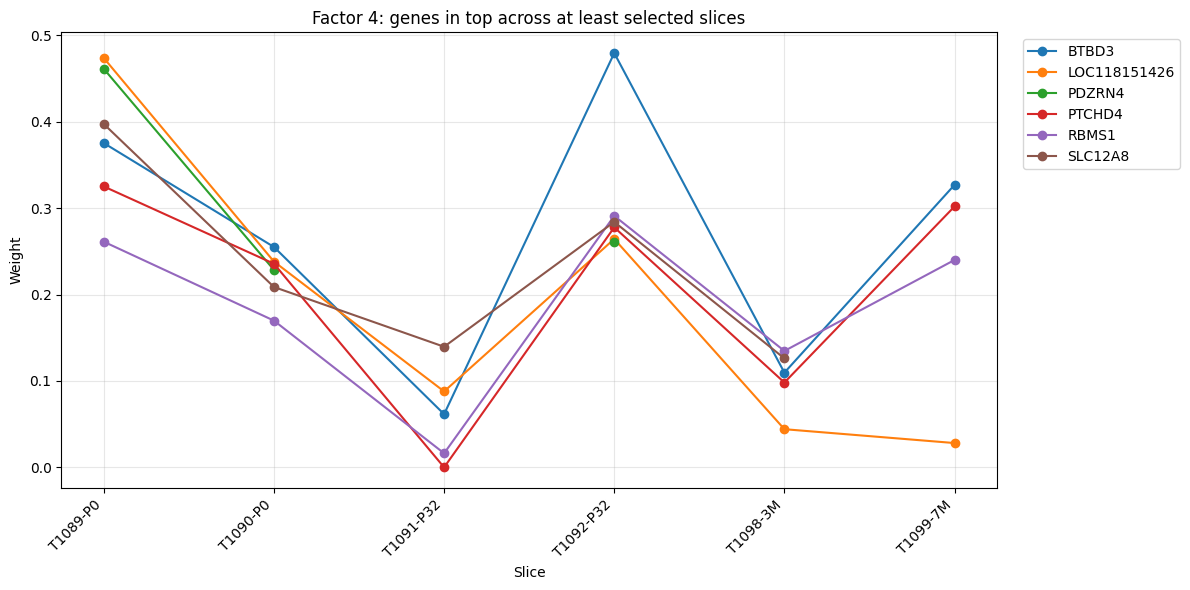

Factor 5: selected 3 genes


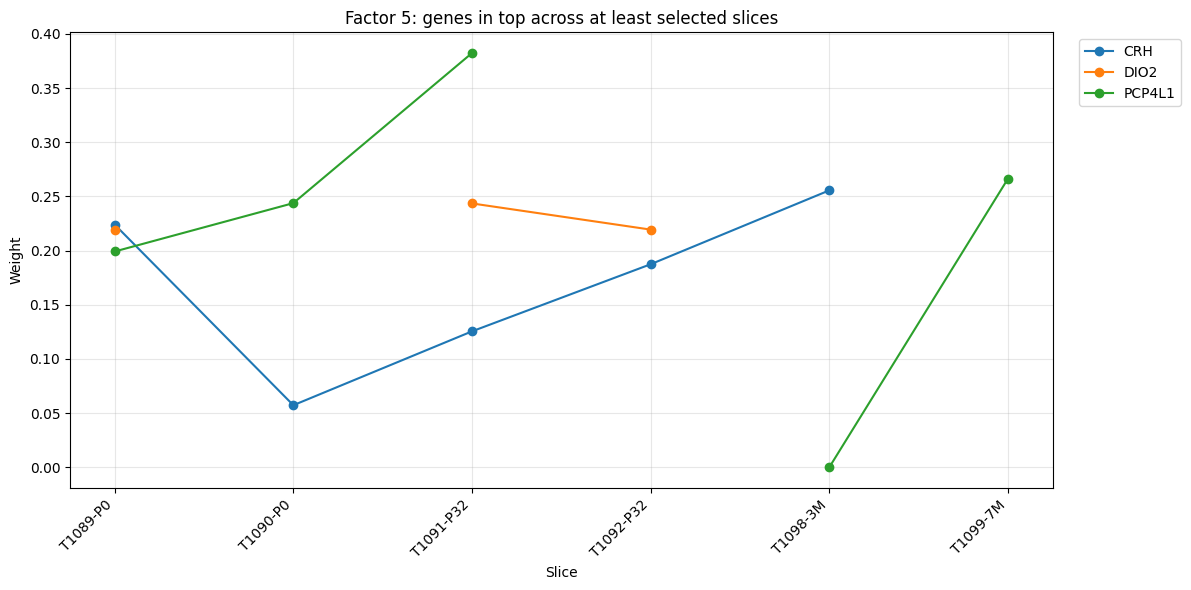

Factor 6: selected 5 genes


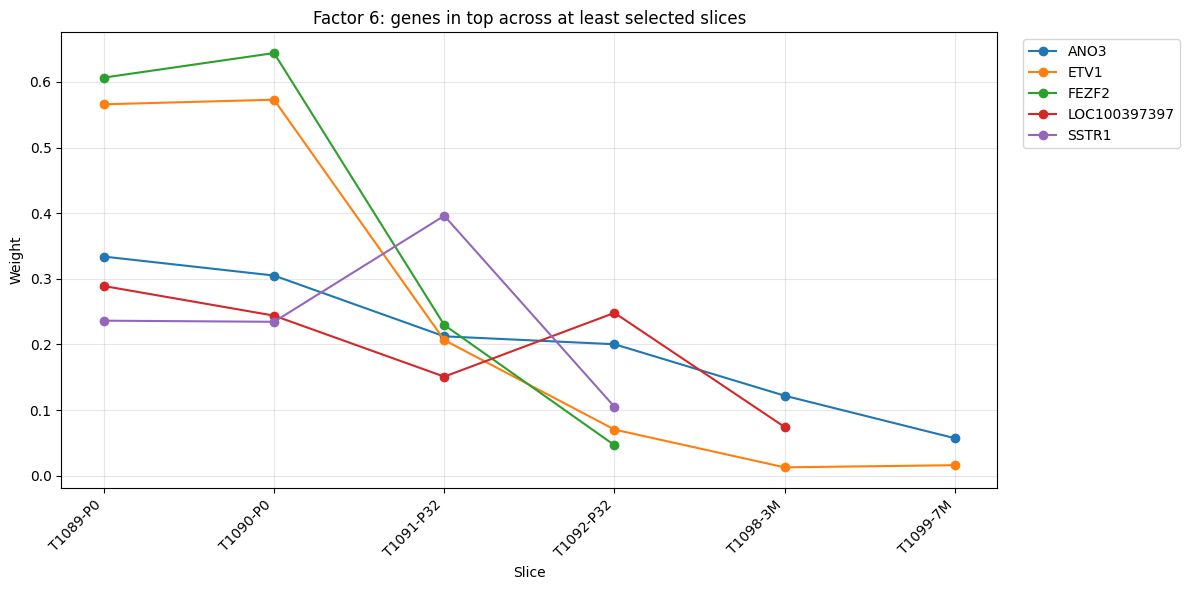

Factor 7: selected 3 genes


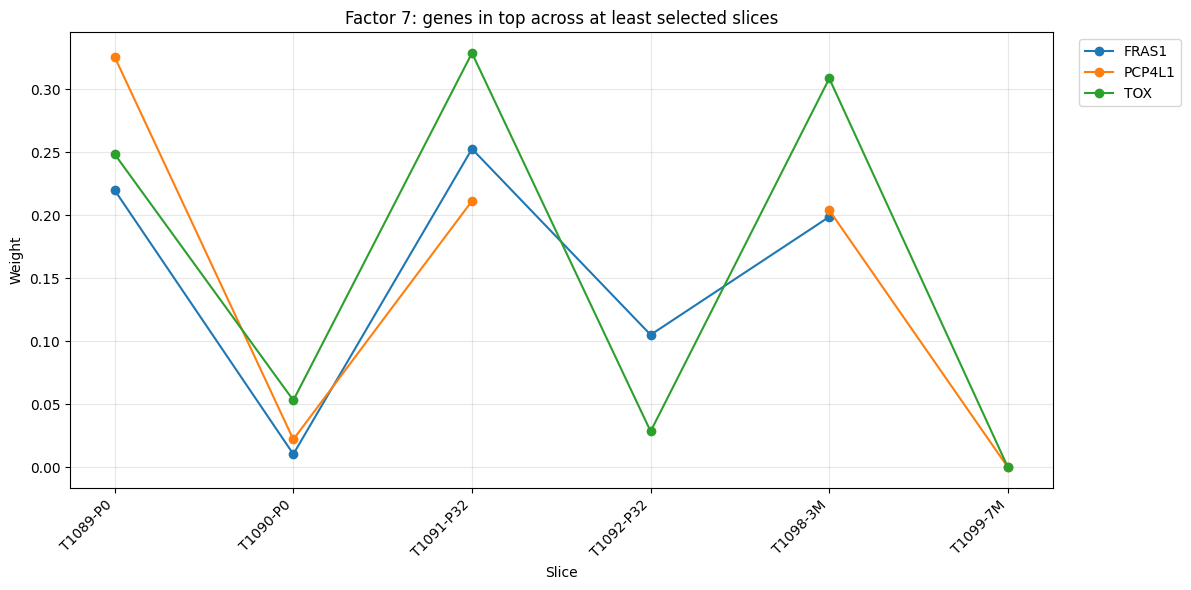

Factor 8: selected 3 genes


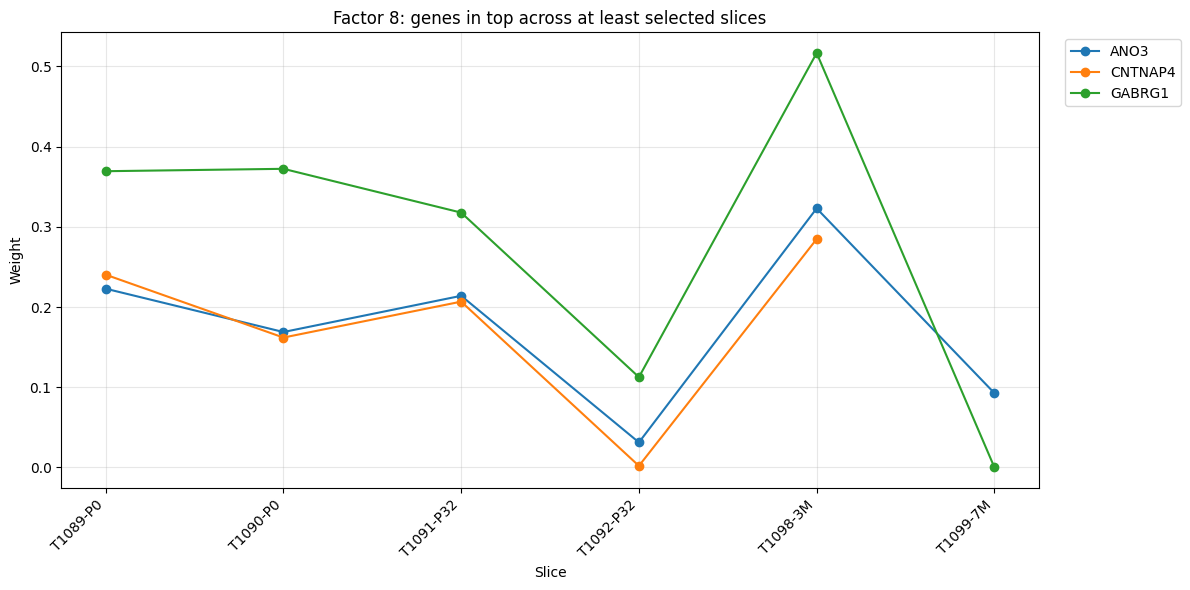

Factor 9: selected 9 genes


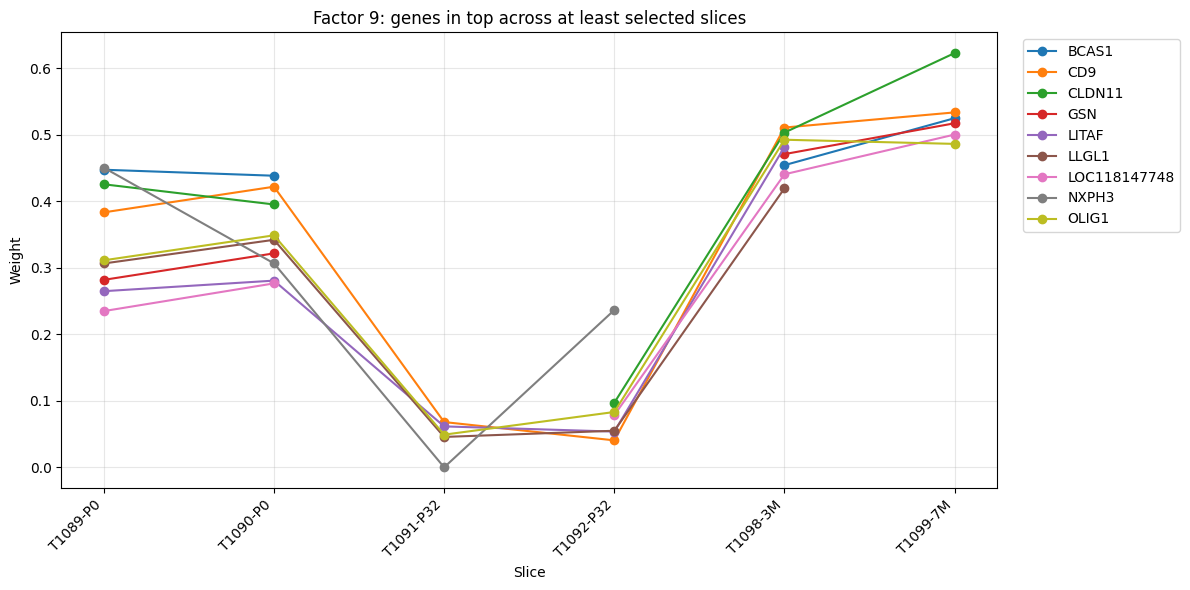

Factor 10: selected 36 genes


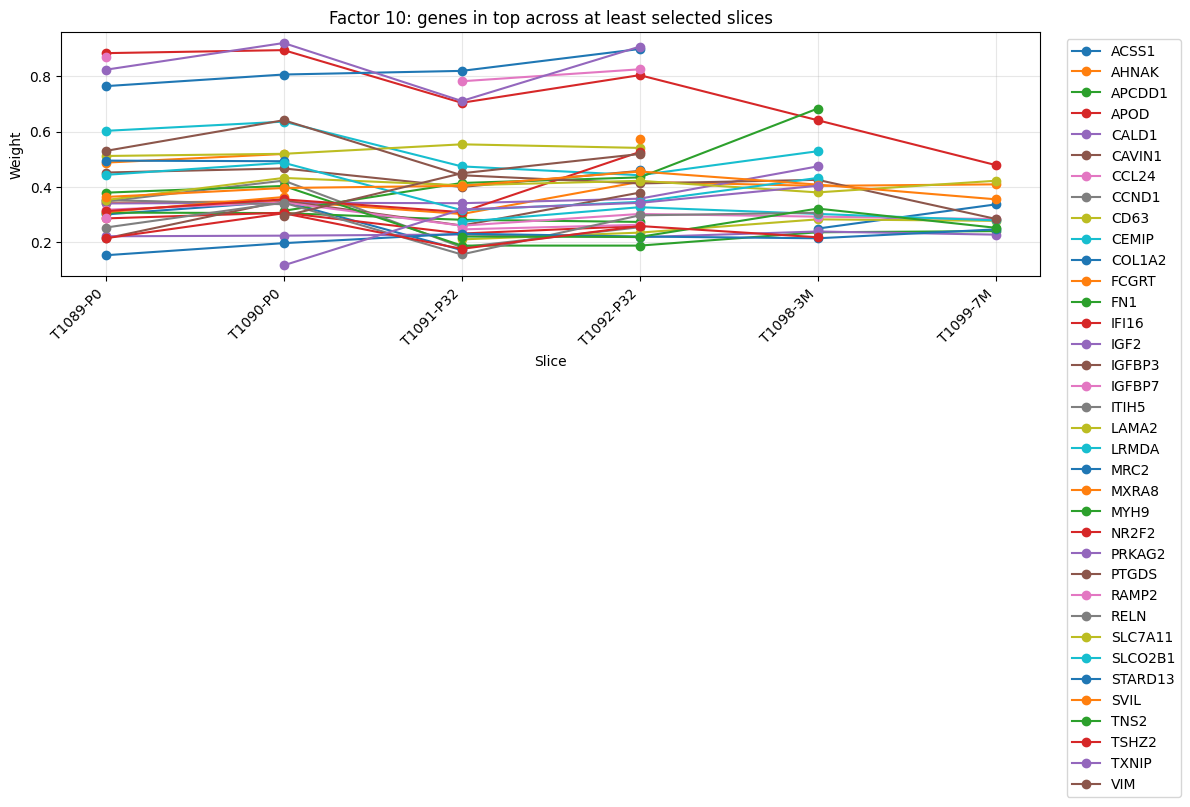

Saved summary: res/top50_genes_at_least_3_slices/summary_top50_present_in_at_least_3_of_6.csv
Saved gene counts: res/top50_genes_at_least_3_slices/gene_counts_top50_present_in_at_least_3_of_6.csv
Saved weights: res/top50_genes_at_least_3_slices/weights_top50_present_in_at_least_3_of_6.csv


In [94]:
selected_genes, summary_df, stats_df, all_weights_df = plot_top_genes_present_in_at_least_k_slices(
    res_dir="res",
    pattern="*_nsfh20_spde_loadings.csv",
    gene_col="Unnamed: 0",
    top_n=50,
    min_slices=3,
    sort_by_abs=False,
    save_dir="res/top50_genes_at_least_3_slices"
)